# SML Project

The term quantamental refers to a hybrid investment approach that combines quantitative models with fundamental macroeconomic research. This strategy helps traders and asset managers identify which economic signals are already priced into markets and which are not, improving decision making.

The following dataset was developed by Macrosynergy, a macroeconomic research and technology company rooted in asset management. In partnership with J.P. Morgan, they created a platform to facilitate the use of such quantamental data.

The dataset we will be using contains a broad set of macroeconomic indicators and their relationships with fixed-income-related assets across multiple countries. The study and later used macro signals were inspired from the following notebook: https://www.kaggle.com/code/macrosynergy/signal-optimization-basics. In this project, we will explore how these indicators relate to asset returns using the models covered in class, focusing on a time series approach rather than the exploration of the entire panel data.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [2]:
############## Note: Multicollinearity and rank-deficiency warnings have been intentionally suppressed for a cleaner layout

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning, SingularMatrixWarning

# Removes all warnings
warnings.filterwarnings('ignore')


## Dataset description

In [3]:
path = kagglehub.dataset_download("macrosynergy/fixed-income-returns-and-macro-trends")
path = os.path.join(path, "JPMaQS_Quantamental_Indicators.csv")

In [4]:
df = pd.read_csv(path, index_col=0, parse_dates=['real_date'])
df = df[['real_date','cid',	'xcat',	'value']] #keep columns relevant to the analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3390059 entries, 0 to 3390058
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   real_date  datetime64[ns]
 1   cid        object        
 2   xcat       object        
 3   value      float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 129.3+ MB


In [5]:
display(df['cid'].unique()) # countries
display(df['xcat'].unique()) # indicators

array(['AUD', 'CAD', 'CHF', 'CLP', 'COP', 'CZK', 'EUR', 'GBP', 'HUF',
       'IDR', 'ILS', 'INR', 'JPY', 'KRW', 'MXN', 'NOK', 'NZD', 'PLN',
       'SEK', 'THB', 'TRY', 'TWD', 'USD', 'ZAR'], dtype=object)

array(['CPIC_SA_P1M1ML12', 'CPIC_SJA_P3M3ML3AR', 'CPIC_SJA_P6M6ML6AR',
       'CPIH_SA_P1M1ML12', 'CPIH_SJA_P3M3ML3AR', 'CPIH_SJA_P6M6ML6AR',
       'DU02YXR_NSA', 'DU02YXR_VT10', 'DU05YXR_NSA', 'DU05YXR_VT10',
       'EQXR_NSA', 'EQXR_VT10', 'FXCRR_NSA', 'FXTARGETED_NSA',
       'FXUNTRADABLE_NSA', 'FXXR_NSA', 'FXXR_VT10', 'INFTEFF_NSA',
       'INTRGDP_NSA_P1M1ML12_3MMA', 'INTRGDPv5Y_NSA_P1M1ML12_3MMA',
       'PCREDITBN_SJA_P1M1ML12', 'PCREDITGDP_SJA_D1M1ML12',
       'RGDP_SA_P1Q1QL4_20QMA', 'RYLDIRS02Y_NSA', 'RYLDIRS05Y_NSA'],
      dtype=object)

In [6]:
# Focus on EUR
dfx = df[df['cid'] == 'EUR'].copy()

In [7]:
# Adding column 'month'
dfx['month'] = dfx['real_date'].dt.to_period('M')

# Defining target variables
rets = ["DU02YXR_NSA", "DU02YXR_VT10", "DU05YXR_NSA", "DU05YXR_VT10", "EQXR_NSA", "EQXR_VT10"]

# Macros downsampling (last of the month)
macro_df = dfx[~dfx['xcat'].isin(rets)]
macro_monthly = (
    macro_df.sort_values('real_date')
    .groupby(['month', 'xcat'])
    .last()
    .reset_index()
)

# Returns da downsamplare (sommati sul mese)
rets_df = dfx[dfx['xcat'].isin(rets)]
rets_monthly = (
    rets_df.groupby(['month', 'xcat'])
    .agg({'value': 'sum'})
    .reset_index()
)

# Pivot in formato largo
macro_wide = macro_monthly.pivot(index='month', columns='xcat', values='value')
#macro_wide = macro_wide.shift(1) done afterwards
rets_wide = rets_monthly.pivot(index='month', columns='xcat', values='value')

# Merge macro + returns
wide_dfx = pd.concat([macro_wide, rets_wide], axis=1)
#wide_dfx.index = wide_dfx.index.to_timestamp()  # per avere datetime di nuovo
wide_dfx.index = wide_dfx.index.to_timestamp(how='end').floor('D') # to end of month

#wide_dfx.dropna(inplace=True) i would drop nans afterwards
wide_dfx_class = wide_dfx.__deepcopy__()
wide_dfx_dup = wide_dfx.__deepcopy__()


Macro downsampling (last of the month): Reduces the frequency of macroeconomic time series by selecting only the value recorded on the last day of each month.

In [8]:
# To ensure validity of the strategy, shift by one month (to avoid look-ahead bias) 
wide_dfx.loc[:, wide_dfx.columns!='DU05YXR_VT10'] = wide_dfx.loc[:, wide_dfx.columns!='DU05YXR_VT10'].shift(1)

# Add lags for AR model
for t in range (1,3,1):
  wide_dfx.insert(t-1, f'L{t}', wide_dfx['DU05YXR_VT10'].shift(t)) 

wide_dfx.dropna(inplace=True)
wide_dfx.head()

xcat,L1,L2,CPIC_SA_P1M1ML12,CPIC_SJA_P3M3ML3AR,CPIC_SJA_P6M6ML6AR,CPIH_SA_P1M1ML12,CPIH_SJA_P3M3ML3AR,CPIH_SJA_P6M6ML6AR,FXCRR_NSA,FXTARGETED_NSA,...,PCREDITGDP_SJA_D1M1ML12,RGDP_SA_P1Q1QL4_20QMA,RYLDIRS02Y_NSA,RYLDIRS05Y_NSA,DU02YXR_NSA,DU02YXR_VT10,DU05YXR_NSA,DU05YXR_VT10,EQXR_NSA,EQXR_VT10
month,,,,,,,,,,,,,,,,,,,,,
2002-02-28,-0.538171,-3.058007,2.055458,2.392955,2.262907,1.931662,0.917643,2.078519,1.212646,0.0,...,6.150412,3.309306,2.237630,2.946439,-0.383210,-1.713091,-0.269767,0.040699,-3.831397,-1.318895
2002-03-31,0.040699,-0.538171,2.420358,2.683964,2.380992,2.653498,1.524118,1.914345,0.921862,0.0,...,4.941121,3.309306,1.947577,2.840953,0.067789,0.441888,0.014848,-5.227853,-0.864654,-0.360068
2002-04-30,-5.227853,0.040699,2.478093,2.935176,2.479239,2.457765,2.368548,1.846195,0.591843,0.0,...,4.814726,3.309306,2.375961,3.167824,-0.692798,-6.210442,-1.324648,4.252356,1.972339,0.819617
2002-05-31,4.252356,-5.227853,2.508197,3.143811,2.561528,2.469443,3.531120,1.772863,0.737865,0.0,...,4.677025,3.309306,2.128406,2.985756,0.496204,5.269928,0.825460,-0.738941,-4.440541,-2.472351
2002-06-30,-0.738941,4.252356,2.393024,2.697311,2.611543,2.368234,3.335143,1.911398,1.038062,0.0,...,4.406957,3.234289,2.344892,3.061224,-0.251973,-2.460131,-0.177580,5.515213,-3.771438,-2.082047


In this preliminary phase, we filtered and adjusted the dataset to improve efficiency. The result is a lighter and more readable dataset suitable for our analysis.

More precisely, we selected only the columns essential to our work and discarded the others. For our analysis we will exclusively focus on data related to the Euro area. We removed missing values (NaNs) to have better integrity and avoid issues with packages that do not internally handle missing data. Lastly, we split the cleaned dataset into three subsets:


*   Training sample (70%)
*   Test sample (30%)

The training and test sets will be used to develop and refine our models. In line with a real life approach we decide to split using the first 70% of the observations for the training and the last 30% for testing. We will study and describe the training sample and avoid looking at the test sample to ensure validity of results. Here is a breakdown of the dates: 

In [9]:
# splitting into train(70%) and test(30%) sample
split_index_70 = int(len(wide_dfx) * 0.7)

train = wide_dfx.iloc[:split_index_70]
test = wide_dfx.iloc[split_index_70:]


The train/test split is done at 2017-06-30.


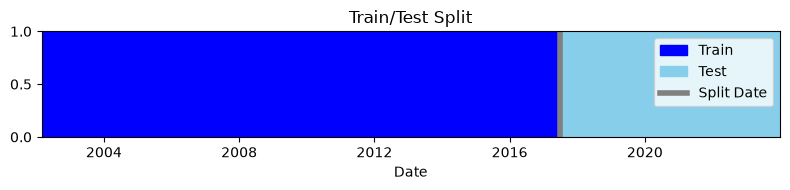

In [10]:
plt.figure(figsize=(8, 2))
plt.axvspan(train.index[0], train.index[-1], color='blue', label='Train')
plt.axvspan(test.index[0], test.index[-1], color='skyblue', label='Test')
plt.axvline(wide_dfx.index[split_index_70],color='gray', linestyle='-', label='Split Date', linewidth=4)

plt.xlabel('Date')
plt.title('Train/Test Split')
plt.xlim(wide_dfx.index[0], wide_dfx.index[-1])
plt.legend()
plt.tight_layout()
print('The train/test split is done at', wide_dfx.index[split_index_70].strftime('%Y-%m-%d.'))
plt.show()

In [11]:
train.describe() # we are allowed to look and explore the training set

xcat,L1,L2,CPIC_SA_P1M1ML12,CPIC_SJA_P3M3ML3AR,CPIC_SJA_P6M6ML6AR,CPIH_SA_P1M1ML12,CPIH_SJA_P3M3ML3AR,CPIH_SJA_P6M6ML6AR,FXCRR_NSA,FXTARGETED_NSA,...,PCREDITGDP_SJA_D1M1ML12,RGDP_SA_P1Q1QL4_20QMA,RYLDIRS02Y_NSA,RYLDIRS05Y_NSA,DU02YXR_NSA,DU02YXR_VT10,DU05YXR_NSA,DU05YXR_VT10,EQXR_NSA,EQXR_VT10
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.0,...,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000
mean,0.521650,0.505685,1.430732,1.402632,1.424416,1.705630,1.707934,1.696482,0.156479,0.0,...,3.401581,1.464185,0.362210,0.788775,0.058444,0.420513,0.167919,0.532358,0.475631,0.328568
std,3.300630,3.310842,0.446314,0.493604,0.460335,1.004875,1.410507,1.109725,0.919797,0.0,...,4.276966,0.989942,1.257613,1.324463,0.356011,3.268084,0.862071,3.300369,5.329372,2.587458
min,-12.833274,-12.833274,0.709824,0.177332,0.559534,-0.617105,-2.812314,-1.257299,-1.758487,0.0,...,-4.390990,-0.313580,-1.462787,-1.195919,-0.862407,-12.170948,-2.031570,-12.833274,-19.588873,-8.639208
25%,-1.792080,-1.889257,1.035368,1.045230,1.010329,0.875645,0.878182,0.928751,-0.463561,0.0,...,0.295877,0.683951,-0.868635,-0.629395,-0.128736,-1.433284,-0.394368,-1.792080,-2.748080,-1.391342
50%,0.844104,0.844104,1.452960,1.412733,1.431685,1.961118,1.752405,1.912872,0.161408,0.0,...,3.301950,1.488162,0.446684,1.102294,0.048392,0.632549,0.136603,0.870236,1.580477,0.825234
75%,2.845493,2.845493,1.786000,1.705798,1.723155,2.371535,2.694776,2.408440,0.813582,0.0,...,6.282698,2.273424,1.190527,1.890402,0.195087,2.436490,0.696059,2.845493,3.703841,2.044194
max,8.652836,8.652836,2.508197,3.143811,2.641390,4.075584,5.262727,4.247607,2.796919,0.0,...,11.368702,3.309306,3.084622,3.167824,1.695461,10.198316,2.665027,8.652836,16.031524,7.531783


Variables official labels:

Returns
* DU02YXR_NSA: Duration return, in % of notional (2-year maturity)
* DU02YXR_VT10: Duration return for 10% vol target (2-year maturity)
* DU05YXR_NSA: Duration return, in % of notional (5-year maturity)
* DU05YXR_VT10: Duration return for 10% vol target (5-year maturity)
* EQXR_NSA: Equity index future returns in % of notional
* EQXR_VT10: Equity index future return for 10% vol target

Inflation related
* CPIC_SA_P1M1ML12: Annual core consumer price inflation
* CPIC_SJA_P3M3ML3AR: Adjusted latest core consumer price trend (% 3m/3m ar)
* CPIC_SJA_P6M6ML6AR: Adjusted latest core consumer price trend (% 6m/6m ar)
* CPIH_SA_P1M1ML12: Standard annual headline consumer price inflation
* CPIH_SJA_P3M3ML3AR: Adjusted headline consumer price trend (% 3m/3m ar)
* CPIH_SJA_P6M6ML6AR: Adjusted headline consumer price trend (% 6m/6m ar)
* INFTEFF_NSA: Effective official inflation target (Macrosynergy method), % over a year ago

Quantmental indicators
* INTRGDP_NSA_P1M1ML12_3MMA: Intuitive real GDP growth: % oya, 3mma
* INTRGDPv5Y_NSA_P1M1ML12_3MMA: Excess intuitive real GDP growth trend (based on 5 year lookback)
* PCREDITBN_SJA_P1M1ML12: Private bank credit, jump-adjusted, % over a year ago
* PCREDITGDP_SJA_D1M1ML12: Banks' private credit expansion, jump-adjusted, as % of GDP over 1 year
* RGDP_SA_P1Q1QL4_20QMA: Long-term real GDP growth: 5-year moving average
* RYLDIRS02Y_NSA: Real IRS yield (2-year maturity)
* RYLDIRS05Y_NSA: Real IRS yield (5-year maturity)

We will try to predict the variable DU05YXR_VT10, which is the return on a fixed receiver position in main interest rate swaps contract traded in the currency area. It is expressed as a percentage of risk capital on a position scaled to 10% (annualized) volatility target (risk-adjusted return). All the other variables may be used as predictors and therefore lagged by one month. The equity based returns may give us important signals regarding market risk sentiment, which often provides insightful information regarding fixed-income volatility. As for the inflation related variables, the dataset presents both headline and core indicators, alongside the official inflation target (proxy for market credibility and forward guidance anchoring). In particular, central banks gradually lose credibility when they miss their targets consistently on either the high or low side for several years. Additionally, the quantative fundamental indicators GDP growth and private credit expansion measure the cyclical strength of the economy and may help in forecasting movements in the fixed income variable. Lastly, the real IRS yields hold key details regarding the long term expectations of market partecipants, we expect this predictor to be structurally important in our analysis. Inflatio nexpectations were computed using Macrosynergy's own method. 


In [12]:
rets = ["DU02YXR_NSA" , "DU02YXR_VT10" , "DU05YXR_NSA" ,
        "DU05YXR_VT10" , "EQXR_NSA" , "EQXR_VT10"
        ] # returns related to our target  

Y_train = train['DU05YXR_VT10'] # selected response variable from rets
X_train = train.drop(columns = rets) # predictors

Y_test = test['DU05YXR_VT10']
X_test = test.drop(columns = rets)

In [13]:
# AR regression, coherent with literature
X_train_sm = X_train[['L1']].copy()
X_train_sm.insert(0, 'intercept', np.ones((X_train.shape[0], 1))) # adding vector of 1s for the intercept
model1 = sm.OLS(Y_train, X_train_sm)
results1 = model1.fit()
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           DU05YXR_VT10   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7865
Date:                Tue, 29 Sep 2026   Prob (F-statistic):              0.376
Time:                        18:50:32   Log-Likelihood:                -479.89
No. Observations:                 184   AIC:                             963.8
Df Residuals:                     182   BIC:                             970.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4981      0.246      2.021      0.045       0.012       0.984
L1             0.0656      0.074      0.887      0.376      -0.080       0.212
==============================================================================
Omnibus:                       10.833   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.500
Skew:                          -0.503   Prob(JB):                      0.00318
Kurtosis:                       3.698   Cond. No.                         3.38
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

By fitting a simple regression with one lagged value we have poor results. In fact, it is quite the usual result as it is not really effective in efficient markets and long horizons. While IRS returns can show to have weak very short-term autocorrelation (due to small inefficiencies, delayed reactions or periods of lower liquidity), we will need other predictors to get to more useful and better at forecasting results. 
Very naively, we decide to see what happens by simply including all the available predictors in a OLS regression: quite clearly there are strong multicollinearity issues, which we will further address. 

In [14]:
# naive regression

X_train_sm = X_train.copy()
X_train_sm.insert(0, 'intercept', np.ones((X_train.shape[0], 1))) # adding vector of 1s for the intercept

model1 = sm.OLS(Y_train, X_train_sm)
results1 = model1.fit()
results1.summary() #  full of redundancy

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           DU05YXR_VT10   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     1.406
Date:                Tue, 29 Sep 2026   Prob (F-statistic):              0.130
Time:                        18:50:33   Log-Likelihood:                -466.40
No. Observations:                 184   AIC:                             972.8
Df Residuals:                     164   BIC:                             1037.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
intercept                        8.2963      5.462      1.519      0.131      -2.488      19.081
L1                               0.0137      0.084      0.163      0.871      -0.153       0.180
L2                               0.0224      0.081      0.277      0.782      -0.137       0.182
CPIC_SA_P1M1ML12                -0.3433      2.504     -0.137      0.891      -5.287       4.601
CPIC_SJA_P3M3ML3AR              -2.5167      1.143     -2.201      0.029      -4.774      -0.259
CPIC_SJA_P6M6ML6AR               2.4542      2.273      1.080      0.282      -2.034       6.942
CPIH_SA_P1M1ML12                 0.7224      0.903      0.800      0.425      -1.061       2.506
CPIH_SJA_P3M3ML3AR              -0.0934      0.284     -0.329      0.742      -0.654       0.467
CPIH_SJA_P6M6ML6AR              -0.3084      0.620     -0.498      0.619      -1.532       0.915
FXCRR_NSA                        0.3316      0.500      0.664      0.508      -0.655       1.319
FXTARGETED_NSA               -1.289e-14   7.59e-15     -1.699      0.091   -2.79e-14    2.09e-15
FXUNTRADABLE_NSA              1.529e-14   1.25e-14      1.219      0.225   -9.48e-15    4.01e-14
FXXR_NSA                        -2.1491      1.271     -1.691      0.093      -4.658       0.360
FXXR_VT10                        1.6096      1.113      1.446      0.150      -0.588       3.808
INFTEFF_NSA                     -4.3767      3.053     -1.434      0.154     -10.404       1.651
INTRGDP_NSA_P1M1ML12_3MMA       -0.8629      1.134     -0.761      0.448      -3.103       1.377
INTRGDPv5Y_NSA_P1M1ML12_3MMA     0.8934      1.114      0.802      0.424      -1.306       3.093
PCREDITBN_SJA_P1M1ML12          -0.5480      1.673     -0.328      0.744      -3.852       2.756
PCREDITGDP_SJA_D1M1ML12          0.1819      1.511      0.120      0.904      -2.802       3.166
RGDP_SA_P1Q1QL4_20QMA            0.5214      1.430      0.365      0.716      -2.303       3.345
RYLDIRS02Y_NSA                  -1.2582      1.642     -0.766      0.445      -4.500       1.984
RYLDIRS05Y_NSA                   2.7011      1.725      1.566      0.119      -0.705       6.107
==============================================================================
Omnibus:                       12.829   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               14.372
Skew:                          -0.544   Prob(JB):                     0.000757
Kurtosis:                       3.832   Cond. No.                     1.99e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.84e-33. This might indicate that there are
strong m

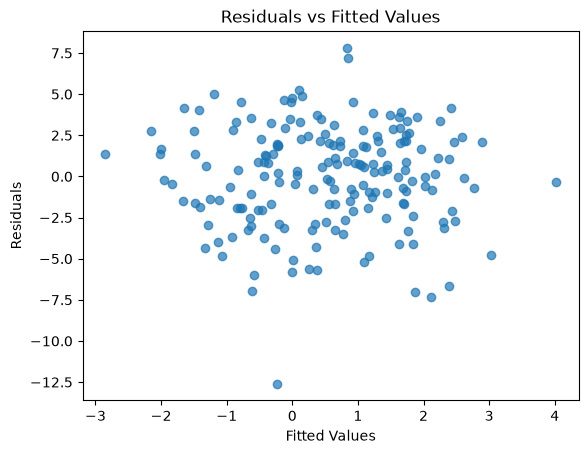

In [15]:
fitted_vals = results1.fittedvalues
residuals = results1.resid
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

By plotting the residuals we can obtain information regarding the correctness of the used model. In the plot we do not notice particular patterns that may refer to heteroskedasticity, but we do notice potential candidates for outliers (the real value is extremely far from the value predicted by the model). 

### Multicollinearity

In [16]:
# Variance inflation factor
vals = [VIF(X_train, i) for i in range(0, X_train.shape[1])] # VIF(dataframe, col index)
vif = pd. DataFrame ({'VIF ':vals},
                     index = X_train.columns)
vif

,VIF
xcat,
L1,1.355633
L2,1.254822
CPIC_SA_P1M1ML12,21.864192
CPIC_SJA_P3M3ML3AR,5.576420
CPIC_SJA_P6M6ML6AR,19.167237
CPIH_SA_P1M1ML12,14.424764
CPIH_SJA_P3M3ML3AR,2.803516
CPIH_SJA_P6M6ML6AR,8.276741
FXCRR_NSA,3.700715


The Variance Infaltion Factor (VIFs) measures how much the variance of a regression coefficient is inflated due to multicollinearity. Here, we notice that most of the variables suffer from multicollinearity: in fact some of these present extreme values. We have redundant predictors when:
1. they measure the same signal (e.g. CPIC_SJA_P3M3ML3AR and CPIC_SJA_P6M6ML6AR refer to the same CPI signal);
2. they are derived ratio variables (e.g. PCREDITBN_SJA_P1M1ML12 (credit volume) and PCREDITGDP_SJA_D1M1ML12 (credit-to-GDP ratio)).

We proceed by removing such redundancies by focusing on predictors that are more coherent with the response variable.

In [17]:
X_train[['FXTARGETED_NSA', 'FXUNTRADABLE_NSA']].describe()
# we drop it since it is all zeros, then do again teh analysis
X_train.drop(columns=['FXTARGETED_NSA', 'FXUNTRADABLE_NSA'], inplace=True)
X_test.drop(columns=['FXTARGETED_NSA', 'FXUNTRADABLE_NSA'], inplace=True)

In [18]:
# Variance inflation factor
vals = [VIF(X_train, i) for i in range(0, X_train.shape[1])] # VIF(dataframe, col index)
vif = pd. DataFrame ({'VIF ':vals},
                     index = X_train.columns)
vif

,VIF
xcat,
L1,1.355633
L2,1.254822
CPIC_SA_P1M1ML12,21.864192
CPIC_SJA_P3M3ML3AR,5.576420
CPIC_SJA_P6M6ML6AR,19.167237
CPIH_SA_P1M1ML12,14.424764
CPIH_SJA_P3M3ML3AR,2.803516
CPIH_SJA_P6M6ML6AR,8.276741
FXCRR_NSA,3.700715


## Regression analysis

Before continuing, we re-scale the parameters using z-scores. First we manually compute them to check if there are any potential outliers, we consider values > 3 as extreme. Then we use StandardScaler() to fit the data and have it on hand to use it later on with the test sample. Including the extreme values in the standardization would imply shrinking the real effect of the regressors in predicting the response variable.

In [19]:
z_scores = (X_train - X_train.mean())/X_train.std()
#display((z_scores >= 3).any(axis=0)) # check for potential outliers

scaler = StandardScaler(with_mean=True, with_std=True)
# fitted on inliers
inlier_mask = z_scores.abs() < 3
scaler.fit(X_train.where(inlier_mask))  # NaN dove outlier, ignorati dallo scaler
X_z_train = scaler.transform(X_train) # np.array
X_z_train = pd.DataFrame(X_z_train, columns = z_scores.columns, index=X_train.index)


X_z_test = scaler.transform(X_test) # np.array
X_z_test = pd.DataFrame(X_z_test, columns = X_test.columns, index=X_test.index)

In [20]:
# NOTICE: StandardScaler() uses biased estimator for the standard deviation (ddof=0 and instead of ddof=1)
# But the choice of ddof is unlikely to affect model performance.

X_z_train.std(axis=0, ddof=0).head() # != 1 when there are outliers

xcat
L1                    1.045404
L2                    1.044963
CPIC_SA_P1M1ML12      1.000000
CPIC_SJA_P3M3ML3AR    1.061396
CPIC_SJA_P6M6ML6AR    1.000000
dtype: float64

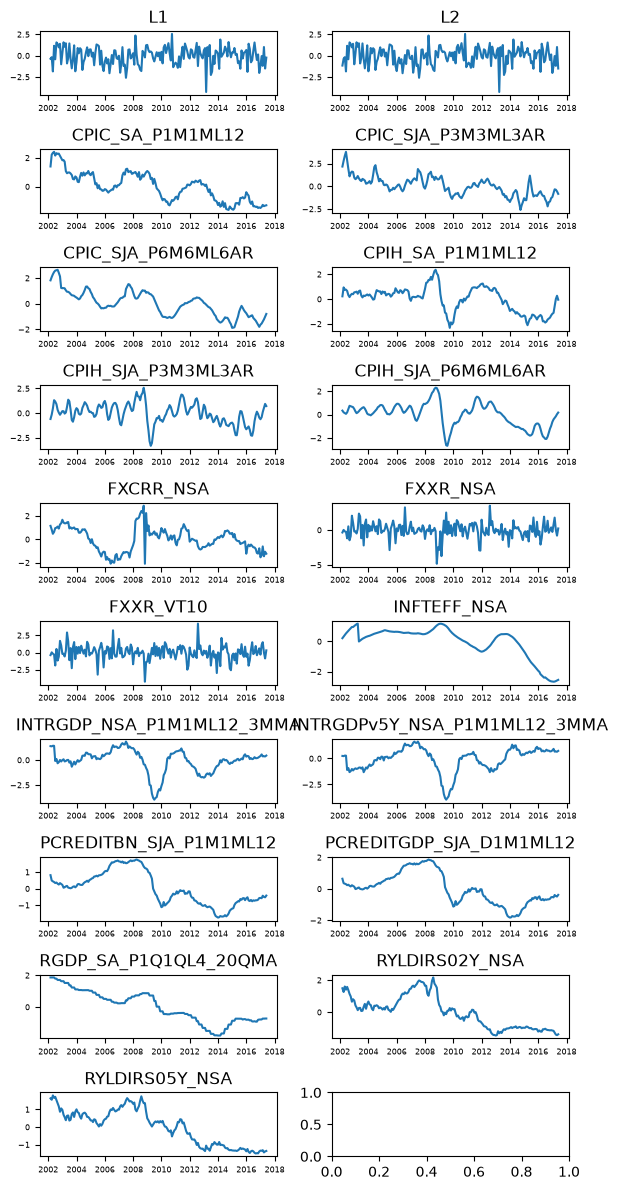

In [21]:
fig, axes = plt.subplots(10, 2, figsize=(6, 12))
axes = axes.flatten()  # flatten in case of multiple rows

for num_plot, var in enumerate(X_z_train.columns):
    axes[num_plot].plot(X_z_train[var])
    axes[num_plot].set_title(var)
    axes[num_plot].tick_params(labelsize=6)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector, ExhaustiveFeatureSelector

In [23]:
# BEST SUBSET SELECTION, computationally expensive

K = 10

model = LinearRegression()
best_subset_selection = ExhaustiveFeatureSelector(model,
                                                  min_features=1,
                                                  max_features=6,
                                                  print_progress=True,
                                                  scoring='neg_mean_squared_error',
                                                  cv=K, # supports only k-fold
                                                  n_jobs=-1) #faster
best_subset_selection.fit(X_z_train, Y_train)
pd.DataFrame.from_dict(best_subset_selection.subsets_).T.tail()

Features: 43795/43795

,feature_idx,cv_scores,avg_score,feature_names
43790,"(12, 13, 14, 15, 17, 18)","[-11.906242882815338, -7.834305461313929, -9.2...",-11.947757,"(INTRGDP_NSA_P1M1ML12_3MMA, INTRGDPv5Y_NSA_P1M..."
43791,"(12, 13, 14, 16, 17, 18)","[-12.016863806481464, -8.289996524714821, -8.8...",-11.837129,"(INTRGDP_NSA_P1M1ML12_3MMA, INTRGDPv5Y_NSA_P1M..."
43792,"(12, 13, 15, 16, 17, 18)","[-11.904455500538111, -8.265624253105056, -8.8...",-11.817125,"(INTRGDP_NSA_P1M1ML12_3MMA, INTRGDPv5Y_NSA_P1M..."
43793,"(12, 14, 15, 16, 17, 18)","[-11.775364451937316, -7.995868148256455, -9.8...",-11.206679,"(INTRGDP_NSA_P1M1ML12_3MMA, PCREDITBN_SJA_P1M1..."
43794,"(13, 14, 15, 16, 17, 18)","[-11.983628862126569, -8.05475703998647, -9.99...",-11.160811,"(INTRGDPv5Y_NSA_P1M1ML12_3MMA, PCREDITBN_SJA_P..."


In [24]:
print(f' The best features are: {best_subset_selection.best_feature_names_}.')

 The best features are: ('FXCRR_NSA', 'PCREDITBN_SJA_P1M1ML12', 'RYLDIRS05Y_NSA').


Since we are using a simple k-fold method for cross-validation, the estimations suffer from look-ahead bias but nonetheless bring to very low scores. Furthermore, the existence of high correlation amongst the variables is again apparent. Models are not nested: when two variables are highly correlated they might explain a lot alone, but they can get dropped later on because when used together they do not add much explanatory power. 

In [25]:
K = 10

fwd_selection = SequentialFeatureSelector(model,
                                          k_features = X_train.shape[1], # no. features
                                          forward=True,
                                          floating=False,
                                          scoring='neg_mean_squared_error',
                                          cv=K)
fwd_selection.fit(X_train, Y_train)
fwd_selection_results = pd.DataFrame.from_dict(fwd_selection.get_metric_dict()).T
fwd_selection_results.head()

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(8,)","[-11.907878919443732, -7.923573760731201, -8.8...",-10.552143,"(FXCRR_NSA,)",3.467785,4.669078,1.556359
2,"(8, 15)","[-11.998497083798668, -7.968032199663185, -9.1...",-10.50003,"(FXCRR_NSA, PCREDITGDP_SJA_D1M1ML12)",3.632662,4.891072,1.630357
3,"(8, 15, 18)","[-11.244431707990936, -7.918863245601522, -8.9...",-10.355291,"(FXCRR_NSA, PCREDITGDP_SJA_D1M1ML12, RYLDIRS05...",3.414974,4.597972,1.532657
4,"(1, 8, 15, 18)","[-11.242434574729616, -7.990387113016978, -8.9...",-10.381265,"(L2, FXCRR_NSA, PCREDITGDP_SJA_D1M1ML12, RYLDI...",3.416822,4.600461,1.533487
5,"(1, 4, 8, 15, 18)","[-11.422596225990498, -7.944612425130931, -9.0...",-10.477034,"(L2, CPIC_SJA_P6M6ML6AR, FXCRR_NSA, PCREDITGDP...",3.587575,4.830365,1.610122


In [26]:
fwd_selection_results.loc[fwd_selection_results['avg_score'] == np.max(fwd_selection_results['avg_score'])] # pops best feature set

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
3,"(8, 15, 18)","[-11.244431707990936, -7.918863245601522, -8.9...",-10.355291,"(FXCRR_NSA, PCREDITGDP_SJA_D1M1ML12, RYLDIRS05...",3.414974,4.597972,1.532657


In [27]:
K = 10

model = LinearRegression()
bwd_selection = SequentialFeatureSelector(model,
                                          k_features = 1, # no. features
                                          forward=False,
                                          floating=False,
                                          #verbose=2,
                                          scoring='neg_mean_squared_error',
                                          cv=K)
bwd_selection.fit(X_train, Y_train)
bwd_selection_results = pd.DataFrame.from_dict(bwd_selection.get_metric_dict()).T
bwd_selection_results.tail()

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
5,"(1, 2, 4, 14, 18)","[-11.360276914761231, -7.643785066377693, -9.0...",-10.453185,"(L2, CPIC_SA_P1M1ML12, CPIC_SJA_P6M6ML6AR, PCR...",3.594765,4.840046,1.613349
4,"(2, 4, 14, 18)","[-11.338143181522254, -7.537204746748411, -9.1...",-10.442802,"(CPIC_SA_P1M1ML12, CPIC_SJA_P6M6ML6AR, PCREDIT...",3.603907,4.852355,1.617452
3,"(4, 14, 18)","[-11.159170580964997, -7.614886212448423, -9.0...",-10.434023,"(CPIC_SJA_P6M6ML6AR, PCREDITBN_SJA_P1M1ML12, R...",3.630944,4.888758,1.629586
2,"(14, 18)","[-11.127687362427432, -7.668255827719616, -9.0...",-10.419954,"(PCREDITBN_SJA_P1M1ML12, RYLDIRS05Y_NSA)",3.433671,4.623147,1.541049
1,"(14,)","[-13.40638559308569, -7.904130458414289, -9.52...",-10.956263,"(PCREDITBN_SJA_P1M1ML12,)",3.842321,5.17336,1.724453


Tho choose the appropriate subset one can select the model with the lowest MSE after Cross-Validation. 

In [28]:
bwd_selection_results.loc[bwd_selection_results['avg_score'] == np.max(bwd_selection_results['avg_score'])] # pops best feature set from CV

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
2,"(14, 18)","[-11.127687362427432, -7.668255827719616, -9.0...",-10.419954,"(PCREDITBN_SJA_P1M1ML12, RYLDIRS05Y_NSA)",3.433671,4.623147,1.541049


In [29]:
print(f'Best MSE from forward selection: {-np.max(fwd_selection_results['avg_score']):.4f}')
print(f'Best MSE from backward selection: {-np.max(bwd_selection_results['avg_score']):.4f}')

Best MSE from forward selection: 10.3553
Best MSE from backward selection: 10.4200


In [30]:
# now we focus on fewer features, seen as important from the best subset selections
sel_cols = ['FXCRR_NSA', 'PCREDITBN_SJA_P1M1ML12', 'RYLDIRS05Y_NSA' ] 


X_z_train = X_z_train.loc[:,sel_cols] ####### !! overwriting original
X_z_test = X_z_test.loc[:,sel_cols] ####### !! overwriting original

In [31]:
# LASSO, RIDGE, ELASTICNET
from sklearn.linear_model import LassoCV, lasso_path, RidgeCV, ElasticNetCV, enet_path
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit # expanding window, suitable for time series

In [32]:
# ELASTIC-NET
eps = 1e-4
K = 5
elastic_net = ElasticNetCV(cv=TimeSeriesSplit(n_splits=K), l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                           max_iter=1000, eps = eps, random_state=0, n_jobs=-1)
#CV search over a grid of alpha values alpha_min / alpha_max = eps, alphas are generated automatically, l1 ratios are specified
elastic_net.fit(X_z_train, Y_train)

enet_best_alpha = elastic_net.alpha_
l1_ratio = elastic_net.l1_ratio_
enet_alphas = elastic_net.alphas_
print(f'Elastic_Net lambda: {enet_best_alpha:.4f}, selected L1 Ratio: {l1_ratio}') #preferred: l2 penalty -> RIDGE

Elastic_Net lambda: 0.0188, selected L1 Ratio: 0.1


In [33]:
enet_coefs = pd.DataFrame({
    'Predictor': X_z_train.columns,
    'ElasticNet Coefficient': elastic_net.coef_
})
enet_coefs

,Predictor,ElasticNet Coefficient
0,FXCRR_NSA,0.325808
1,PCREDITBN_SJA_P1M1ML12,-1.122468
2,RYLDIRS05Y_NSA,0.924353


In [34]:
Y_pred_enet = elastic_net.predict(X_z_test)
enet_test_mse = mean_squared_error(Y_test, Y_pred_enet)
print(f'The Test MSE is: {enet_test_mse:.4f}')

The Test MSE is: 16.1334


The Elastic-Net regression suggests a Ridge regression may fit better instead of a Lasso regression (in fact we have already selected fewer variables so Lasso might be too penalizing). 

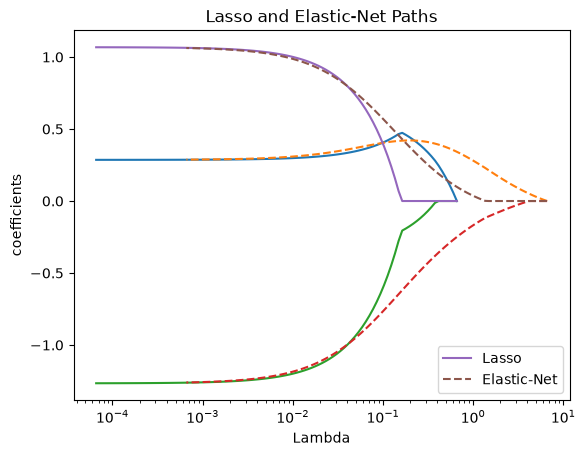

In [35]:
alphas_lasso, coefs_lasso, _ = lasso_path(X_z_train, Y_train, eps=eps)
alphas_enet, coefs_enet, _ = enet_path(X_z_train, Y_train, eps=eps, l1_ratio=l1_ratio)

for coef_l, coef_e in zip(coefs_lasso, coefs_enet):
    l1 = plt.semilogx(alphas_lasso, coef_l,)
    l2 = plt.semilogx(alphas_enet, coef_e, linestyle="--",)

plt.xlabel("Lambda")
plt.ylabel("coefficients")
plt.title("Lasso and Elastic-Net Paths")
plt.legend((l1[-1], l2[-1]), ("Lasso", "Elastic-Net"), loc="lower right")
plt.show()

In [36]:
# RIDGE
eps = 1e-4
ridge = RidgeCV(cv=TimeSeriesSplit(), alphas = enet_alphas[0], # we use the same alphas as for elastic-net with l1_ratio=0.1
                scoring='r2', )
ridge.fit(X_z_train, Y_train)

print(f'Ridge lambda: {ridge.alpha_:.4f}')

Ridge lambda: 1.1258


In [37]:
Y_pred_ridge = ridge.predict(X_z_test)
ridge_test_mse = mean_squared_error(Y_test, Y_pred_ridge)
print(f'The Test MSE is: {ridge_test_mse:.4f}')

The Test MSE is: 16.1395


In [38]:
ridge_coefs = pd.DataFrame({
    'Predictor': X_z_train.columns,
    'Ridge Coefficient': ridge.coef_
})
ridge_coefs

,Predictor,Ridge Coefficient
0,FXCRR_NSA,0.301190
1,PCREDITBN_SJA_P1M1ML12,-1.213831
2,RYLDIRS05Y_NSA,1.016007


The Ridge regression imposes a great deal of penalization. It leads to greater coefficients (in absolute value) compared to the Elastic-Net, but the Test MSE is still quite high. We want to see if we can improve the performance using macroeconomic signals. 

In [39]:
## BUILDING SIGNALS

wide_dfx['XGDP_NEG'] = - wide_dfx["INTRGDPv5Y_NSA_P1M1ML12_3MMA"]
wide_dfx['XCPI_NEG'] = - (wide_dfx['CPIC_SJA_P6M6ML6AR'] + wide_dfx['CPIH_SA_P1M1ML12']) / 2 + wide_dfx['INFTEFF_NSA']
wide_dfx['XPCG_NEG'] = - wide_dfx['PCREDITBN_SJA_P1M1ML12'] + wide_dfx['INFTEFF_NSA'] + wide_dfx['RGDP_SA_P1Q1QL4_20QMA']

In [40]:
train = wide_dfx.iloc[:split_index_70]
test = wide_dfx.iloc[split_index_70:]

Y_train = train['DU05YXR_VT10'] # selected response variable from rets
X_train = train[['XGDP_NEG','XCPI_NEG','XPCG_NEG', 'RYLDIRS05Y_NSA']] # new predictors

Y_test = test['DU05YXR_VT10']
X_test = test[['XGDP_NEG','XCPI_NEG','XPCG_NEG', 'RYLDIRS05Y_NSA']]

### Linear Regression

In [41]:
X_train_sm = X_train.copy()
X_train_sm.insert(0, 'intercept', np.ones((X_train.shape[0], 1))) # adding vector of 1s for the intercept
model1 = sm.OLS(Y_train, X_train_sm)
results1 = model1.fit(cov_type='HC3')
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           DU05YXR_VT10   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     3.788
Date:                Tue, 29 Sep 2026   Prob (F-statistic):            0.00554
Time:                        18:51:32   Log-Likelihood:                -472.97
No. Observations:                 184   AIC:                             955.9
Df Residuals:                     179   BIC:                             972.0
Df Model:                           4                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          0.2206      0.355      0.621      0.535      -0.476       0.917
XGDP_NEG          -0.0157      0.132     -0.119      0.905      -0.274       0.243
XCPI_NEG          -0.5102      0.463     -1.103      0.270      -1.417       0.396
XPCG_NEG           0.3803      0.108      3.516      0.000       0.168       0.592
RYLDIRS05Y_NSA     0.6869      0.329      2.090      0.037       0.043       1.331
==============================================================================
Omnibus:                       13.650   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.922
Skew:                          -0.549   Prob(JB):                     0.000349
Kurtosis:                       3.934   Cond. No.                         8.85
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [42]:
X_test_sm = X_test.copy()
X_test_sm.insert(0, 'intercept', np.ones((X_test.shape[0], 1)))

Y_pred = results1.predict(X_test_sm)

mse = mean_squared_error(Y_test, Y_pred)
print("Test MSE:", mse)

Test MSE: 15.59162043405802


### Locally Weighted Scatterplot Smoothing

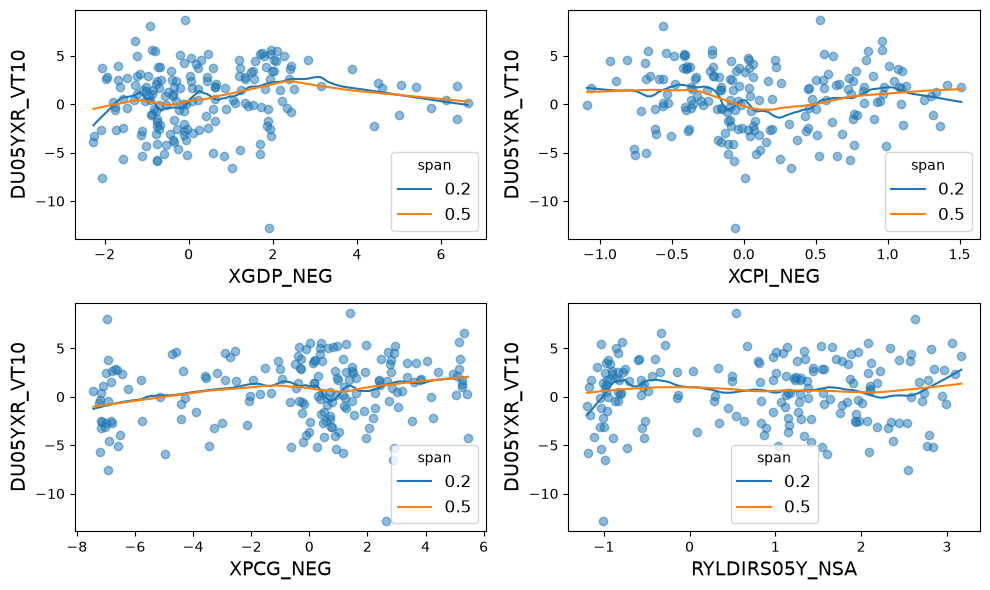

In [43]:
# Fitting on the singular predictors
lowess = sm.nonparametric.lowess

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(X_train.columns):
    ax = axes[i]
    ax.scatter(X_train[col], Y_train, alpha=0.5)

    for span in [0.2, 0.5]: #fraction of data to use
        L2_grid = np.linspace(X_train[col].min(), X_train[col].max(), 100)
        fitted = lowess(Y_train, X_train[col], frac=span, xvals=L2_grid)
        ax.plot(L2_grid, fitted, label=f'{span:.1f}')

    ax.set_xlabel(f'{col}', fontsize=14)
    ax.set_ylabel('DU05YXR_VT10', fontsize=14)
    ax.legend(title='span', fontsize=12)

plt.tight_layout()
plt.show()

We fitted a non-linear regression using LOESS (Locally Estimated Scatterplot Smoothing) to visualize relationships between individual predictors and the target variable using two different spans for smoothing:
- 0.2: more flexible and follows short-term trends
- 0.5: includes half of the observations so it is less sensitive to noise and smoother

LOESS modifies the lambda value to keep the fraction of involved observations constant. Another approach could be to take a model and find lambda using cross-validation.

### Decision Tree

Before implementing Random Forest and Gradient Boosting regressions, we briefly introduce decision trees. 

In [44]:
# DECISION TREE
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


dt = DecisionTreeRegressor(max_depth = 6, # arbitrarily chosen
                           random_state=0,
                           ccp_alpha=0)  # cost-complexity pruning parameter, set to 0 for initial fit
dt.fit(X_train, Y_train)
path = dt.cost_complexity_pruning_path(X_train, Y_train) #finds the effective alphas for pruning
ccp_alphas, impurities = path.ccp_alphas, path.impurities 
#impurity = sum of all impurities(MSE_i) at each terminal (leaf) node in the tree, weighted by the number of samples in each node.

dtps = []
for ccp_alpha in ccp_alphas:
    dtp = DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha) #compute the tree for each alpha, we let nodes grow to their full size
    dtp.fit(X_train, Y_train)
    dtps.append(dtp)
print(
    f"Number of nodes in the last tree is: {dtps[-1].tree_.node_count} with ccp_alpha: {ccp_alphas[-1]:.4f}")
  

Number of nodes in the last tree is: 5 with ccp_alpha: 0.6958


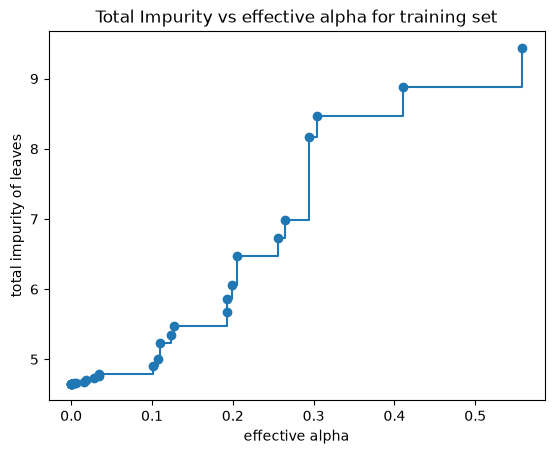

In [45]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set");

Naturally, the lower the alpha the lower the total impurity in the trees, because it better fits the data. However, this denotes the importance of pruning in simple decision trees to avoid overfitting when tested on the holdout set. 

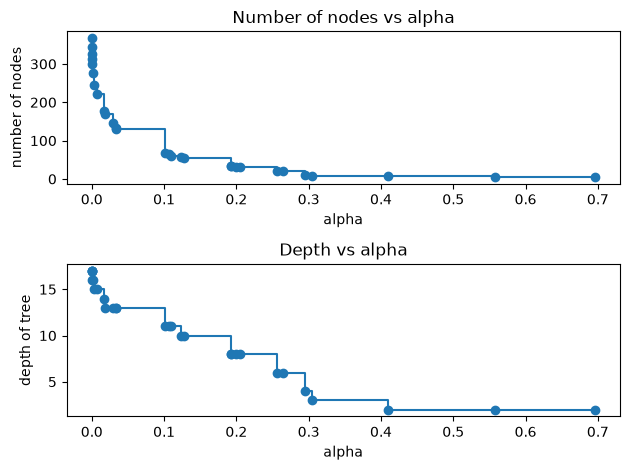

In [46]:
#dps = dtps[:-1]
#ccp_alphas = ccp_alphas[:-1]

node_counts = [dtp.tree_.node_count for dtp in dtps]
depth = [dtp.tree_.max_depth for dtp in dtps]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

We have let the successive trees to have no pre-specified max depth, so the number of nodes for lower alphas is extremely high. 

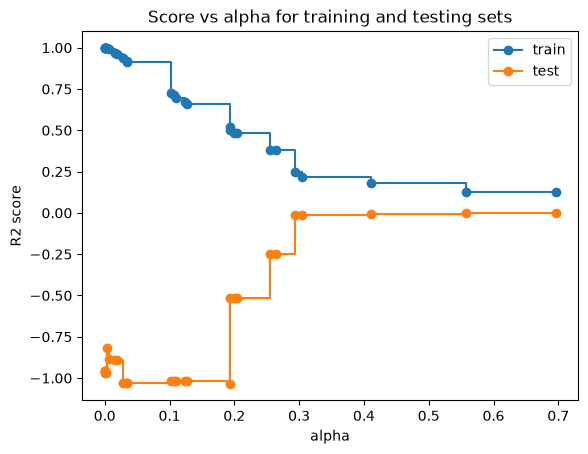

In [47]:
train_scores = [dtp.score(X_train, Y_train) for dtp in dtps]
test_scores = [dtp.score(X_test, Y_test) for dtp in dtps]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("R2 score")
ax.set_title("Score vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

When implemented on the test set, we see that for lower alphas (implying no pruning or minimal pruning) the trees tend to overfit the data and lead to very poor results.

## An intermediate conclusion:

Since predicting the returns seems rather difficult, we shift towards a classification type of setting where we are interested in predicting up and down movements of the market. 

## Classification

Whereas with regression we tried to predict a continuous variable, classification has the aim of predicting a state: a discrete outcome. In this specific case our goal is building a model which helps us recognize if given the current state of the economy we are able to predict if in the following period returns on the IRS will be positive (1) or negative (0).

With this aim, we decided to focus on tree-based classification methods, appreciated both in regression and in classification because of the way in which they work which is, according to many scientists, more similar than regression to the way in which our brain functions.

The simplest model, which allows us to understand the way in which more complex models work, is the decision tree classifier. A tree splits the feature space in recursive binary partitions in which the predicted value will be the most frequent class of the observations that fall in the partition.

### Preparation

In [48]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from scipy.stats import randint
from sklearn.metrics import roc_curve, roc_auc_score

In [49]:
roc_data = {}

In [50]:
# To ensure validity of the strategy, shift by one month (to avoid look-ahead bias) 
wide_dfx_class.loc[:, wide_dfx_class.columns!='DU05YXR_VT10'] = wide_dfx_class.loc[:, wide_dfx_class.columns!='DU05YXR_VT10'].shift(1)

In [51]:
wide_dfx_clean = wide_dfx_class.dropna(how = 'any')

In [52]:
# splitting into train(70%) and test(30%)
split_index_70 = int(len(wide_dfx_clean) * 0.7)

train = wide_dfx_clean.iloc[:split_index_70]
test = wide_dfx_clean.iloc[split_index_70:]

In [53]:
rets = ["DU02YXR_NSA" , "DU02YXR_VT10" , "DU05YXR_NSA" ,
        "DU05YXR_VT10" , "EQXR_NSA" , "EQXR_VT10"] # generic returns

useless = ["FXTARGETED_NSA" , "FXUNTRADABLE_NSA"] # removed because problematic

Y_train = train['DU05YXR_VT10'] # selected response variable from rets
y_class_train = (Y_train > 0).astype(int)
X_train = train.drop(columns = rets + useless) # predictors

Y_test = test['DU05YXR_VT10']
y_class_test = (Y_test > 0).astype(int)
X_test = test.drop(columns = rets + useless)

In [54]:
z_scores = (X_train - X_train.mean())/X_train.std()
# display((z_scores >= 3).any(axis=0)) # checks for potential outliers

scaler = StandardScaler(with_mean=True, with_std=True)
# fitted on inliers
scaler.fit(X_train)
X_z_train = scaler.transform(X_train) # np.array
X_z_train = pd.DataFrame(X_z_train, columns = z_scores.columns, index=X_train.index)

X_z_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184 entries, 2002-02-28 to 2017-05-31
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CPIC_SA_P1M1ML12              184 non-null    float64
 1   CPIC_SJA_P3M3ML3AR            184 non-null    float64
 2   CPIC_SJA_P6M6ML6AR            184 non-null    float64
 3   CPIH_SA_P1M1ML12              184 non-null    float64
 4   CPIH_SJA_P3M3ML3AR            184 non-null    float64
 5   CPIH_SJA_P6M6ML6AR            184 non-null    float64
 6   FXCRR_NSA                     184 non-null    float64
 7   FXXR_NSA                      184 non-null    float64
 8   FXXR_VT10                     184 non-null    float64
 9   INFTEFF_NSA                   184 non-null    float64
 10  INTRGDP_NSA_P1M1ML12_3MMA     184 non-null    float64
 11  INTRGDPv5Y_NSA_P1M1ML12_3MMA  184 non-null    float64
 12  PCREDITBN_SJA_P1M1ML12        184 non-null   

In [55]:
X_z_test = scaler.transform(X_test) # np.array
X_z_test = pd.DataFrame(X_z_test, columns = X_test.columns, index=X_test.index)

In [56]:
# Distribuzione classi nel training set
print(y_class_train.value_counts(normalize=True))

DU05YXR_VT10
1    0.597826
0    0.402174
Name: proportion, dtype: float64


### Decision Tree

In [57]:
dt = DecisionTreeClassifier(max_depth = None)
dt.fit(X_z_train, y_class_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [58]:
y_pred_dt = dt.predict(X_z_test)

In [59]:
accuracy_dt_initial = accuracy_score(y_class_test, y_pred_dt)

In [60]:
y_proba_dt = dt.predict_proba(X_z_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_class_test, y_proba_dt)
auc_dt = roc_auc_score(y_class_test, y_proba_dt)
roc_data['Decision Tree - initial'] = (fpr_dt, tpr_dt, auc_dt)

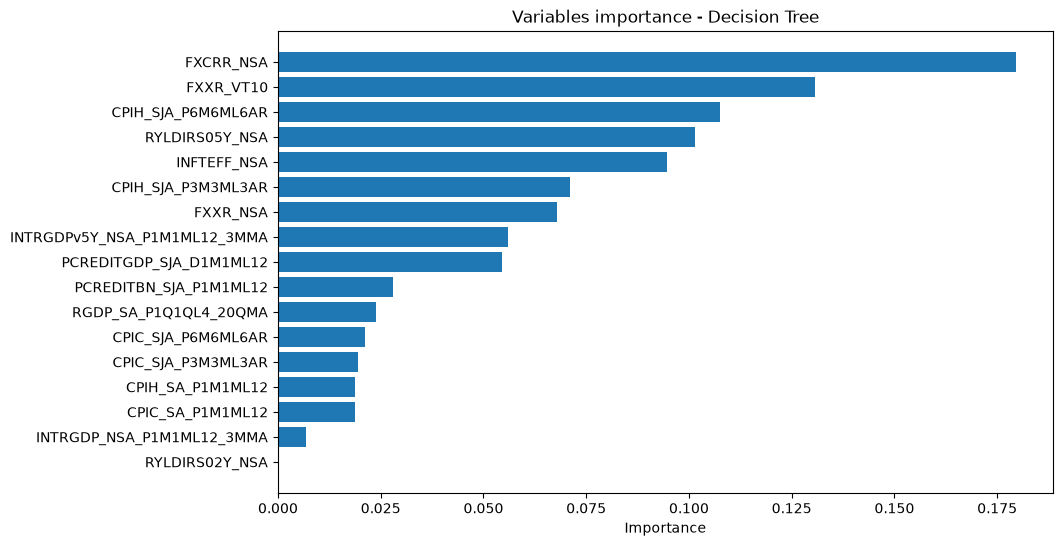

In [61]:
importances = dt.feature_importances_

# Creating a dataframe for a better representation
feature_importance_df_dt = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_dt['Feature'], feature_importance_df_dt['Importance'])
plt.xlabel('Importance')
plt.title('Variables importance - Decision Tree')
plt.gca().invert_yaxis()
plt.show()

While a decision tree is very understandable and often reliable, it tends to overfit and not to perform well in the prediction of classes. For this sake, we decided to use more sound approaches which include random forests and gradient boosting classifiers.

More precisely, boosting builds an ensemble of small trees one after another, where each new tree is trained to correct the residual errors of the combined model so far. By using gradient descent on a chosen loss function (e.g., logistic loss for classification), each tree focuses on examples the previous ensemble misclassified. Adding trees with a small learning rate lets the model gradually reduce bias and improve accuracy, and the final prediction is the weighted sum of all trees’ outputs.

Random Forest grows many decision trees in parallel, each trained on a different bootstrap sample of the data and considering a random subset of features at every split. Because each tree sees a slightly different version of the data and a different feature set, their errors tend to cancel out. At prediction time, every tree votes on the class, and the forest picks the majority vote. This randomization reduces overfitting and stabilizes predictions compared to a single tree.

We will use default parameters for the models (if not specified any), that means that the scoring criterion is GINI.


### Random forest

In [62]:
rf = RandomForestClassifier(max_depth = None,random_state= 23)
rf.fit(X_z_train, y_class_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",23
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [63]:
y_pred_rf = rf.predict(X_z_test)

In [64]:
accuracy_rf_initial = accuracy_score(y_class_test, y_pred_rf)

In [65]:
y_proba_rf = rf.predict_proba(X_z_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_class_test, y_proba_rf)
auc_rf = roc_auc_score(y_class_test, y_proba_rf)
roc_data['Random Forest - initial'] = (fpr_rf, tpr_rf, auc_rf)

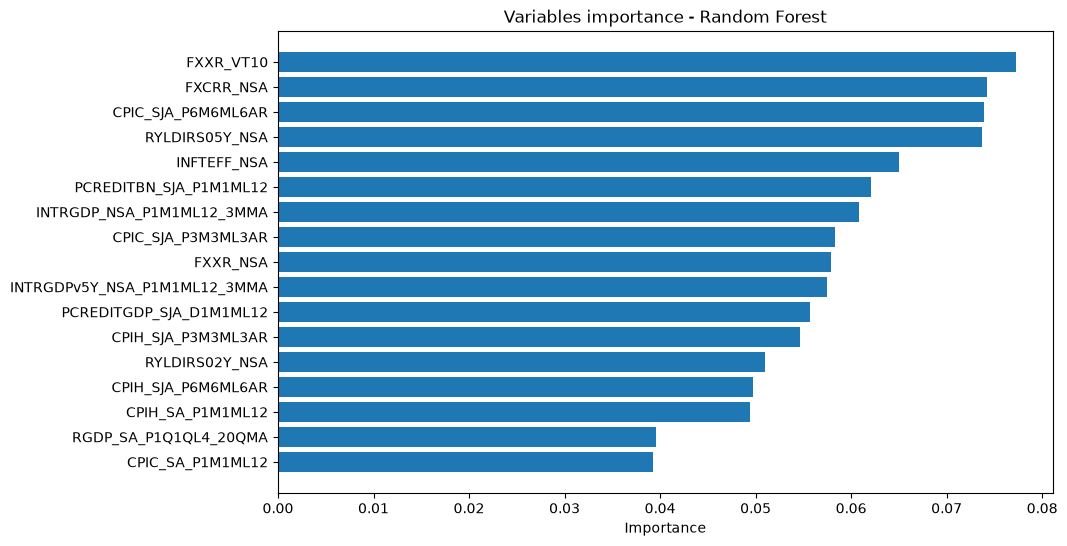

In [66]:
importances = rf.feature_importances_

# Creating a dataframe for a better representation
feature_importance_df_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_rf['Feature'], feature_importance_df_rf['Importance'])
plt.xlabel('Importance')
plt.title('Variables importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

### Gradient Boosting Classifier

In [67]:
gbc = GradientBoostingClassifier(max_depth = None,random_state= 23)
gbc.fit(X_z_train, y_class_train)

,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",23
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * 

In [68]:
y_pred_gbc = gbc.predict(X_z_test)

In [69]:
accuracy_gbc_initial = accuracy_score(y_class_test, y_pred_gbc)

In [70]:
y_proba_gbc = gbc.predict_proba(X_z_test)[:, 1]
fpr_gbc, tpr_gbc, _ = roc_curve(y_class_test, y_proba_gbc)
auc_gbc = roc_auc_score(y_class_test, y_proba_gbc)
roc_data['Gradient Boosting - initial'] = (fpr_gbc, tpr_gbc, auc_gbc)

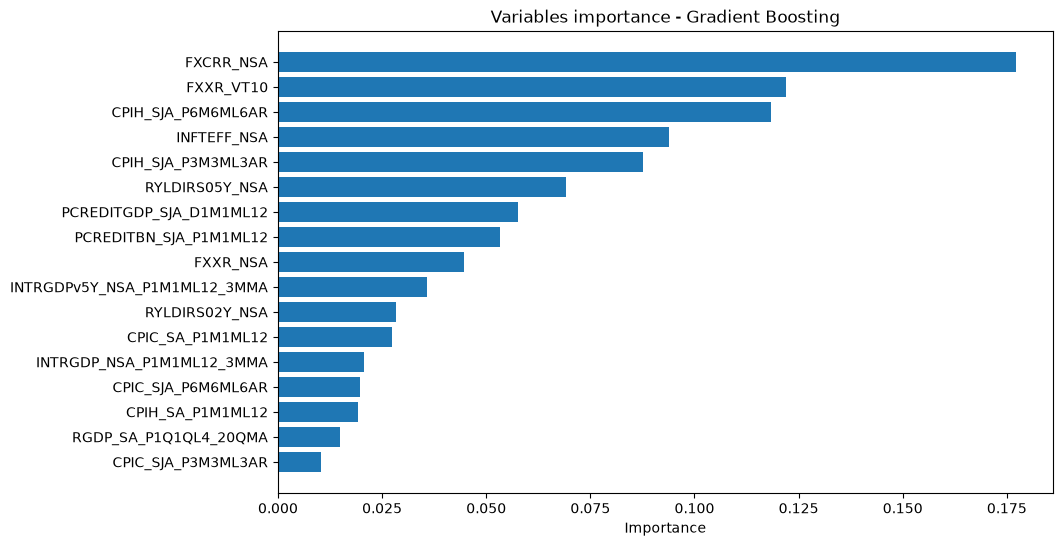

In [71]:
importances = gbc.feature_importances_

# Creating a dataframe for a better representation
feature_importance_df_gbc = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_gbc['Feature'], feature_importance_df_gbc['Importance'])
plt.xlabel('Importance')
plt.title('Variables importance - Gradient Boosting')
plt.gca().invert_yaxis()
plt.show()


### Initial results

We observe that more complex models yield more informative results. However, as highlighted in the dataset description, many variables capture similar information but differ only in their rolling time horizons. This poses a significant risk of multicollinearity, which can undermine the robustness of our analysis. 
\
To address this issue, we reduce the dataset by removing redundant variables and retaining only those identified as most important by our previous models. As example, we remove 'RYLDIRS02Y_NSA', but we keep 'RYLDIRS05Y_NSA' which the models found more important.


## Refinement: removing the main sources of multicollinearity

### Preparation

In [72]:
useless_update = ['RYLDIRS02Y_NSA',
'INTRGDPv5Y_NSA_P1M1ML12_3MMA',
'PCREDITGDP_SJA_D1M1ML12',
'CPIH_SJA_P6M6ML6AR',
'CPIH_SJA_P3M3ML3AR',
'CPIC_SA_P1M1ML12',
'CPIH_SA_P1M1ML12',
'CPIC_SJA_P6M6ML6AR']

In [73]:
rets = ["DU02YXR_NSA" , "DU02YXR_VT10" , "DU05YXR_NSA" ,"DU05YXR_VT10" , "EQXR_NSA" , "EQXR_VT10"]

# 5 yr
Y_train = train['DU05YXR_VT10']
X_train = train.drop(columns = rets + useless + useless_update)
z_scores = (X_train - X_train.mean())/X_train.std()

scaler = StandardScaler(with_mean=True, with_std=True)


inlier_mask = z_scores.abs() < 3
scaler.fit(X_train.where(inlier_mask))  
X_z_train = scaler.transform(X_train) # np.array
X_z_train = pd.DataFrame(X_z_train, columns = z_scores.columns, index=X_train.index)

In [74]:
y_test = test['DU05YXR_VT10']
y_class_test = (y_test > 0).astype(int)

X_test= test.drop(columns = rets + useless + useless_update)
X_z_test = scaler.transform(X_test) #using same scaler as before

X_z_test = pd.DataFrame(X_z_test, columns = z_scores.columns, index=X_test.index)

### Random forest

In [75]:
rf = RandomForestClassifier(max_depth = None)
rf.fit(X_z_train, y_class_train)
y_pred_rf = rf.predict(X_z_test)

In [76]:
accuracy_rf_refined = accuracy_score(y_class_test, y_pred_rf)

In [77]:
y_proba_rf = rf.predict_proba(X_z_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_class_test, y_proba_rf)
auc_rf = roc_auc_score(y_class_test, y_proba_rf)
roc_data['Random Forest - refined'] = (fpr_rf, tpr_rf, auc_rf)

### Gradient Boosting

In [78]:
gbc = GradientBoostingClassifier(max_depth = None,random_state= 23)
gbc.fit(X_z_train, y_class_train)

,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",23
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * 

In [79]:
y_pred_gbc = gbc.predict(X_z_test)

In [80]:
accuracy_gbc_refined = accuracy_score(y_class_test, y_pred_gbc)

In [81]:
y_proba_gbc = gbc.predict_proba(X_z_test)[:, 1]
fpr_gbc, tpr_gbc, _ = roc_curve(y_class_test, y_proba_gbc)
auc_gbc = roc_auc_score(y_class_test, y_proba_gbc)
roc_data['Gradient Boosting - refined'] = (fpr_gbc, tpr_gbc, auc_gbc)

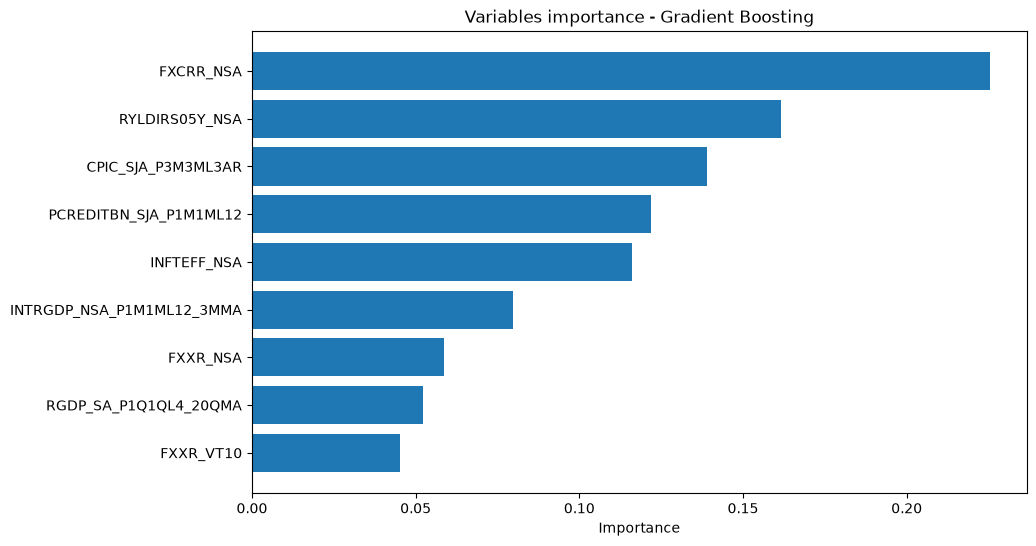

In [82]:
importances = gbc.feature_importances_

# Creating a dataframe for a better representation
feature_importance_df_gbc = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_gbc['Feature'], feature_importance_df_gbc['Importance'])
plt.xlabel('Importance')
plt.title('Variables importance - Gradient Boosting')
plt.gca().invert_yaxis()
plt.show()


## Fundamental refinement

### Preparation

In [83]:
wide_dfx_clean['XGDP_NEG'] = - wide_dfx_clean["INTRGDPv5Y_NSA_P1M1ML12_3MMA"]
wide_dfx_clean['XCPI_NEG'] = - (wide_dfx_clean['CPIC_SJA_P6M6ML6AR'] + wide_dfx_clean['CPIH_SA_P1M1ML12']) / 2 + wide_dfx_clean['INFTEFF_NSA']
wide_dfx_clean['XPCG_NEG'] = - wide_dfx_clean['PCREDITBN_SJA_P1M1ML12'] + wide_dfx_clean['INFTEFF_NSA'] + wide_dfx_clean['RGDP_SA_P1Q1QL4_20QMA']

In [84]:
# splitting into train(70%) and test (30%)
split_index_70 = int(len(wide_dfx_clean) * 0.7)

train = wide_dfx_clean.iloc[:split_index_70]
test = wide_dfx_clean.iloc[split_index_70:]

In [85]:
rets = ["DU02YXR_NSA" , "DU02YXR_VT10" , "DU05YXR_NSA" ,
        "DU05YXR_VT10" , "EQXR_NSA" , "EQXR_VT10"] # generic returns

useless_update = ['RYLDIRS02Y_NSA',
'INTRGDPv5Y_NSA_P1M1ML12_3MMA',
'PCREDITGDP_SJA_D1M1ML12',
'CPIH_SJA_P6M6ML6AR',
'CPIH_SJA_P3M3ML3AR',
'CPIC_SA_P1M1ML12',
'CPIH_SA_P1M1ML12',
'CPIC_SJA_P6M6ML6AR',
'INFTEFF_NSA',
'XPCG_NEG',
'PCREDITBN_SJA_P1M1ML12',
'RGDP_SA_P1Q1QL4_20QMA']



Y_train = train['DU05YXR_VT10'] # selected response variable from rets
y_class_train = (Y_train > 0).astype(int)
X_train = train.drop(columns = rets + useless + useless_update) # predictors

Y_test = test['DU05YXR_VT10']
y_class_test = (Y_test > 0).astype(int)
X_test = test.drop(columns = rets + useless + useless_update)

In [86]:
z_scores = (X_train - X_train.mean())/X_train.std()


scaler = StandardScaler(with_mean=True, with_std=True)
# fitted on inliers
scaler.fit(X_train)
X_z_train = scaler.transform(X_train) # np.array
X_z_train = pd.DataFrame(X_z_train, columns = z_scores.columns, index=X_train.index)

X_z_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184 entries, 2002-02-28 to 2017-05-31
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPIC_SJA_P3M3ML3AR         184 non-null    float64
 1   FXCRR_NSA                  184 non-null    float64
 2   FXXR_NSA                   184 non-null    float64
 3   FXXR_VT10                  184 non-null    float64
 4   INTRGDP_NSA_P1M1ML12_3MMA  184 non-null    float64
 5   RYLDIRS05Y_NSA             184 non-null    float64
 6   XGDP_NEG                   184 non-null    float64
 7   XCPI_NEG                   184 non-null    float64
dtypes: float64(8)
memory usage: 12.9 KB


In [87]:
X_z_test = scaler.transform(X_test) # np.array
X_z_test = pd.DataFrame(X_z_test, columns = X_test.columns, index=X_test.index)

### Random forest

In [88]:
rf = RandomForestClassifier(max_depth = None,random_state= 23)
rf.fit(X_z_train, y_class_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",23
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [89]:
y_pred_rf = rf.predict(X_z_test)

In [90]:
accuracy_rf_final = accuracy_score(y_class_test, y_pred_rf)

In [91]:
y_proba_rf = rf.predict_proba(X_z_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_class_test, y_proba_rf)
auc_rf = roc_auc_score(y_class_test, y_proba_rf)
roc_data['Random Forest - fund_ref'] = (fpr_rf, tpr_rf, auc_rf)

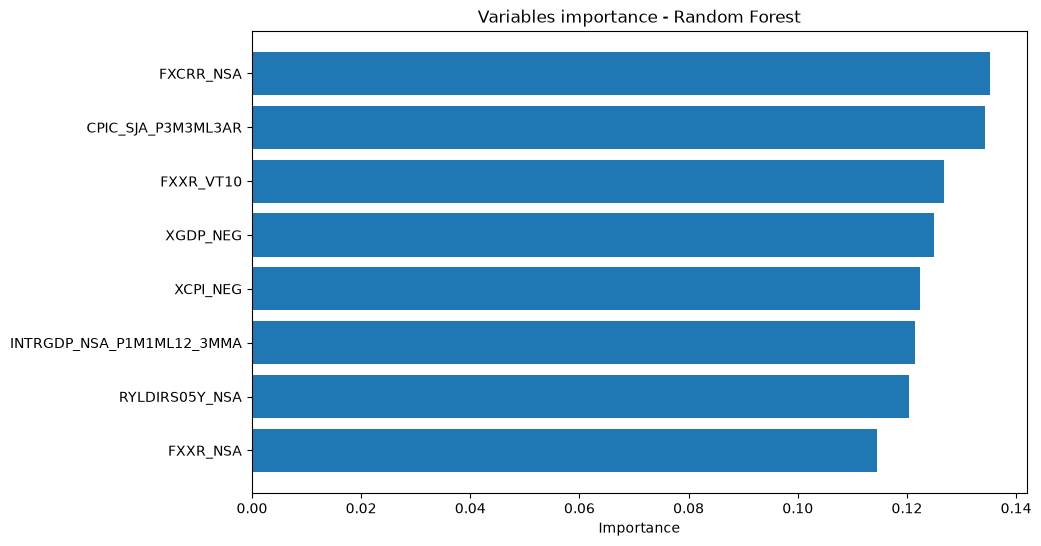

In [92]:
importances = rf.feature_importances_

# Creating a dataframe for a better representation
feature_importance_df_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_rf['Feature'], feature_importance_df_rf['Importance'])
plt.xlabel('Importance')
plt.title('Variables importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

### Gradient Boosting

In [93]:
gbc = GradientBoostingClassifier(max_depth = None,random_state= 23)
gbc.fit(X_z_train, y_class_train)

,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",23
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * 

In [94]:
y_pred_gbc = gbc.predict(X_z_test)

In [95]:
accuracy_gbc_final = accuracy_score(y_class_test, y_pred_gbc)

In [96]:
y_proba_gbc = gbc.predict_proba(X_z_test)[:, 1]
fpr_gbc, tpr_gbc, _ = roc_curve(y_class_test, y_proba_gbc)
auc_gbc = roc_auc_score(y_class_test, y_proba_gbc)
roc_data['Gradient Boosting - fund_ref'] = (fpr_gbc, tpr_gbc, auc_gbc)

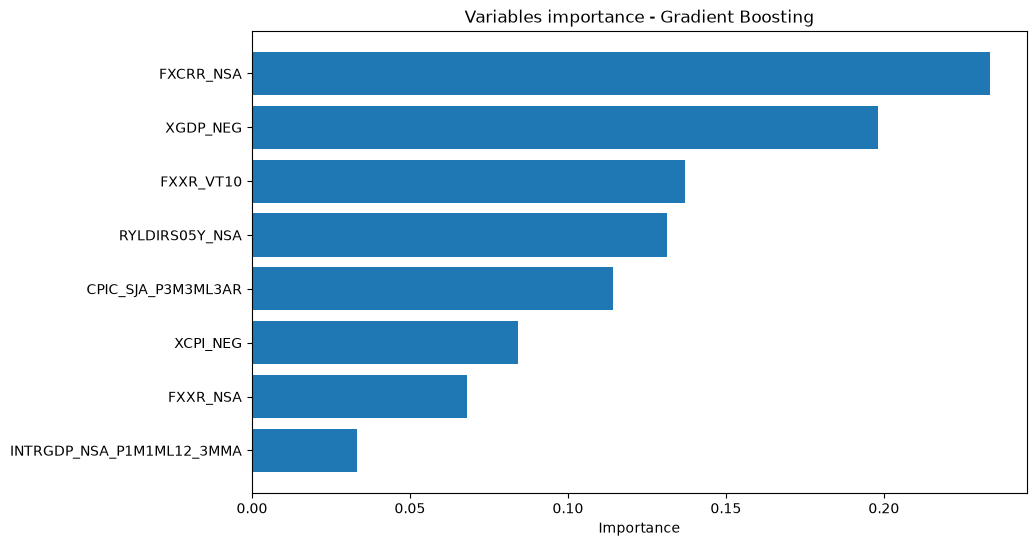

In [97]:
importances = gbc.feature_importances_

# Creating a dataframe for a better representation
feature_importance_df_gbc = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_gbc['Feature'], feature_importance_df_gbc['Importance'])
plt.xlabel('Importance')
plt.title('Variables importance - Gradient Boosting')
plt.gca().invert_yaxis()
plt.show()


### Results for fundamental refinement

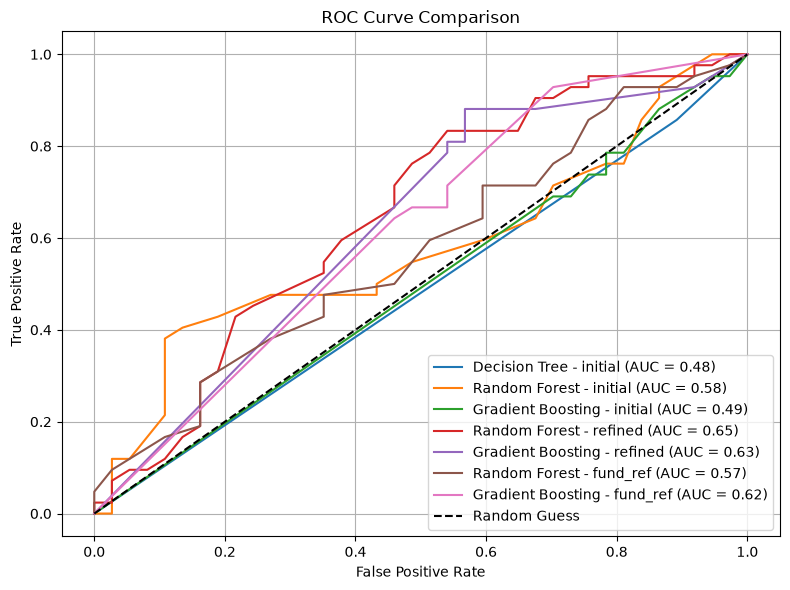

In [98]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
for label, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

Predicting monthly fixed-income returns remains challenging, with the linear models providing limited out-of-sample predictive power.

Tree-based classification models achieved higher predictive performance than the initial regression specifications, although the results were sensitive to feature selection and model refinement.

In particular, reducing highly correlated and redundant macroeconomic variables affected model performance substantially. The results therefore suggest that model specification and feature selection play an important role in extracting information from a highly correlated macroeconomic dataset.

Overall, the analysis provides evidence of some predictive structure in the selected variables, but the results should not be interpreted as evidence of a robust or directly tradable investment strategy. Further validation using rolling time-series cross-validation, multiple markets and longer out-of-sample periods would be required.